# Photoluminescence from monolayer WSe2

We investigate the photoluminescence of WSe2 as a function of two parameters: gate voltage and excitation power. We ground the semiconducting layer and apply a voltage to the bottom gate of our device, which dopes the semiconductor according to

$$
\Delta ne = Q = CV\\
\Delta n = \frac{V}{e}\frac{\epsilon}{d_{\text{hBN}}}
$$

where $e$ is the elementary charge, $\Delta n$ is the carrier density, $Q$ is the total charge, $C$ is the capacitance of the device and $V$ is the applied voltage. We can only calculate the change in carrier density and not an absolute number. We require a reference voltage to calculate the overall carrier density in the device.

This is a nice test to apply to our device because the trion complexes in 1L WSe2 appear only at positive voltages (n-doping).

## What this notebook covers
1. Loading of data
2. Plotting of voltage sweep data
3. Fitting and extracting the PL linewidth
4. Plotting of power sweep data



## References
- Li, Z. et al. Emerging photoluminescence from the dark-exciton phonon replica in monolayer WSe2. Nat Commun 10, 2469 (2019).
- He, M. et al. Valley phonons and exciton complexes in a monolayer semiconductor. Nat Commun 11, 618 (2020).
- Li, Z. et al. Revealing the biexciton and trion-exciton complexes in BN encapsulated WSe2. Nat Commun 9, 3719 (2018).
- Ye, Z. et al. Efficient generation of neutral and charged biexcitons in encapsulated WSe2 monolayers. Nat Commun 9, 3718 (2018).
- Barbone, M. et al. Charge-tuneable biexciton complexes in monolayer WSe2. Nat Commun 9, 3721 (2018).

In [1]:
from tmdc_optics_tools.loaders import AttoCubeSpectralSweep, StackLayer, DeviceGeometry
from tmdc_optics_tools.plotting import plot_spectral_map, plot_spectrum, plot_spectral_series
from tmdc_optics_tools.fitting import fit_lorentzian, lorentzian

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import cmocean, cmcrameri
from pathlib import Path

## Bottom-gate voltage sweep

In [2]:
geom = DeviceGeometry(
    d_hbn_top = 30,
    d_hbn_bottom = 26,
    tmdc_stack = [StackLayer("WSe2")],
    label = "hBN/WSe2(Flux)/hBN"
)

SWEEP_DEFAULTS = dict(
    spectra_type = "PL",                               # 
    gates = {'channel' : "V_B", "bottom" : "V_A"},     # Physical voltage channel mapping
    bg_region_eV = [1.55,1.6],                         #
    apply_jacobian = True,                             #
    curated_scales = {"v_bot" : -1},                   # In our experiment, we swapped the TMDC and back gate leads by accident.
    cosmic_rays = {}
)

We have three scans taken at the following power levels: $1\;\mathrm{\mu}W$, $10\;\mathrm{\mu}W$, $20\;\mathrm{\mu}W$.

In [3]:
filepath = Path('./data/1L-WSe2-PL')

powers = [1, 10, 20]

scans = [
    AttoCubeSpectralSweep(
        path=sorted(filepath.glob(f"PL_{power}uW_*.csv"))[0],
        geometry = geom, 
        sweep = "bottom_voltage",                          # Variable being swept
        **SWEEP_DEFAULTS
    )

    for power in powers
]

C:\Users\Brandon\AppData\Local\Temp\ipykernel_33520\3831421691.py:6: UserWarning: curated_scales rescaled 'v_bot' 1 -> -1, unit still 'V'. Pass curated_units={'v_bot': ...} to state what the numbers now are — the unit reaches every axis label, __repr__ line and legend entry, so it is a misread otherwise.
  AttoCubeSpectralSweep(
C:\Users\Brandon\Documents\02_Areas\LANES-TMDC-Optics-Tools\src\tmdc_optics_tools\loaders.py:4333: UserWarning: 37 flagged pixel(s) kept their raw values because every pixel in their median_window=7 window was flagged too: pixel 547 (sweep 4), pixel 548 (sweep 4), pixel 549 (sweep 4), .... A run of flagged pixels that wide has no unflagged neighbour left to take a median from, so part of the spike survives the repair. Pass a larger median_window to reach it.
  self.spectra_cr, self.cosmic_ray_mask = processing.remove_cosmic_rays(
C:\Users\Brandon\Documents\02_Areas\LANES-TMDC-Optics-Tools\src\tmdc_optics_tools\loaders.py:4333: UserWarning: 133 flagged pixel(s) 

We can check one of the scans:

In [4]:
print(scans[0])

AttoCubeSpectralSweep — 161 sweeps × 1340 pixels  [Photoluminescence]
  File        : data\1L-WSe2-PL\PL_1uW_Vbot_sweep_26_08_05_14_15_15_iter_0.csv
  λ range     : 687.1 – 811.5 nm
  Energy range: 1.528 – 1.804 eV
  Sweep       : bottom_voltage — -20 → 20 V
  Gates       : bottom-gate only  (bottom ← 'V_A', channel ← 'V_B')
  Power       : 1.1 → 1.1 µW
  Varying     : I_A, V_A, V_B, I_B
  ROI         : ExpROI1
  Cosmic rays : 89 pixels replaced
  BG region   : 774.9 – 799.9 nm
  Jacobian    : applied



We can find out more about the scan:

In [5]:
print(scans[0].gate_mode)
print(f"Is our sample dual-gated? {scans[0].is_dual_gated}.")
print(f"The varying parameters are: {scans[0].varying_parameters()}") # Returns a dict of parameters which change (min_val, max_val, span)

bottom-gate only
Is our sample dual-gated? False.
The varying parameters are: {'I_A': (-1.386459e-09, 1.192098e-09, 2.578557e-09), 'V_A': (-19.9998, 19.99987, 39.99967), 'V_B': (1.065262e-06, 1.97613e-06, 9.10868e-07), 'I_B': (1.954806e-12, 2.920041e-12, 9.65235e-13), 'Excitation Power': (3.7213915e-06, 3.7410502e-06, 1.9658699999999684e-08)}


Since we have passed in our device geometry, we could calculate the swept change in carrier density using the equation above using the swept bottom gate voltage and our device geometry.

When viewing this, we only take the first 20 values.

In [6]:
scans[0].carrier_density[:20]

C:\Users\Brandon\AppData\Local\Temp\ipykernel_33520\805908744.py:1: UserWarning: carrier_density references the channel contact, but its row 'V_B' varies by 9.109e-07 V across the sweep, so the reference moves with the axis. The returned density is relative to 0 V on the gates alone and does not account for it. Expected for a source-drain bias; for a doping sweep the channel should be at a fixed potential.
  scans[0].carrier_density[:20]


array([1.65788823e+13, 1.63716193e+13, 1.61643646e+13, 1.59571265e+13,
       1.57499962e+13, 1.55427001e+13, 1.53354786e+13, 1.51279420e+13,
       1.49207454e+13, 1.47135404e+13, 1.45063355e+13, 1.42992383e+13,
       1.40919256e+13, 1.38846792e+13, 1.36774411e+13, 1.34702776e+13,
       1.32630810e+13, 1.30558429e+13, 1.28485302e+13, 1.26413667e+13])

Now we plot our scans at different excitation powers.

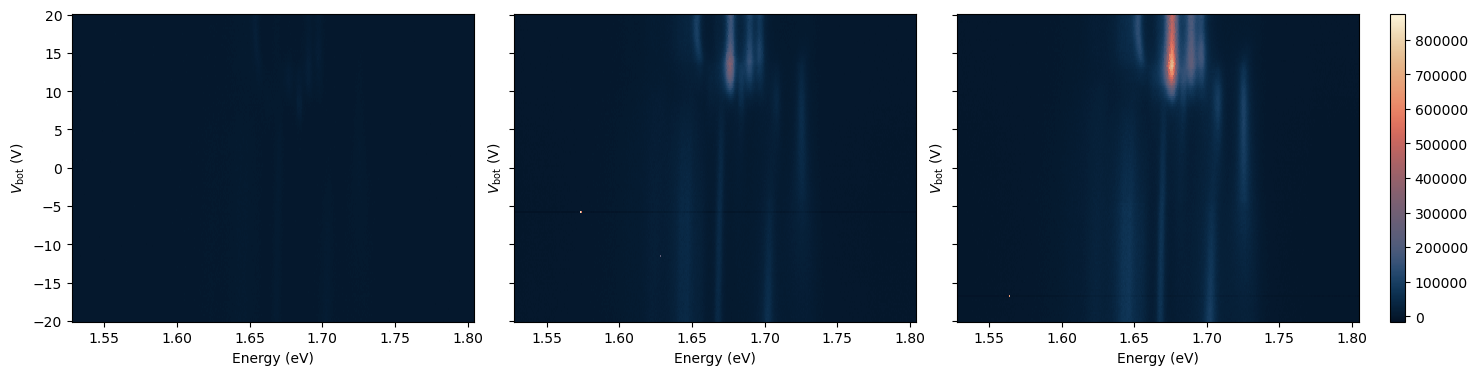

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharey=True, gridspec_kw={'wspace': 0.1})
labels = [rf"{power} $\mu$W" for power in powers]

meshes = []
for ax, scan in zip(axes, scans):
    _, _, mesh = plot_spectral_map(scan, ax=ax, colorbar=False, cmap='cmc.lipari')
    meshes.append(mesh)

## Normalise the colormap the the global minimum and maximum

vmin = min(m.get_array().min() for m in meshes)
vmax = max(m.get_array().max() for m in meshes)
norm = Normalize(vmin, vmax)
for m in meshes:
    m.set_norm(norm)

fig.colorbar(meshes[-1], ax=axes, pad=0.02)

We can also slice our spectral data to analyse the spectra at particular sweeping values. Let's look at the zero gate voltage condition, $V_{\text{bot}}=0\;V$. To do this, we call the `plot_spectrum` function which can plot our spectra at the index of our scan of the value of our sweeping parameter. In the next cell, we call

```python
plot_spectrum(scan, value = 0.0, ...)
```

which gives us the spectrum at $V_{\text{bot}}=0\;V$

If we knew the index at which we wanted to take our spectrum, we could have done

```python
plot_spectrum(scan, index = 30) # For example
```

In our function we pass our created `ax` into the function so that we can draw on the same figure handle.

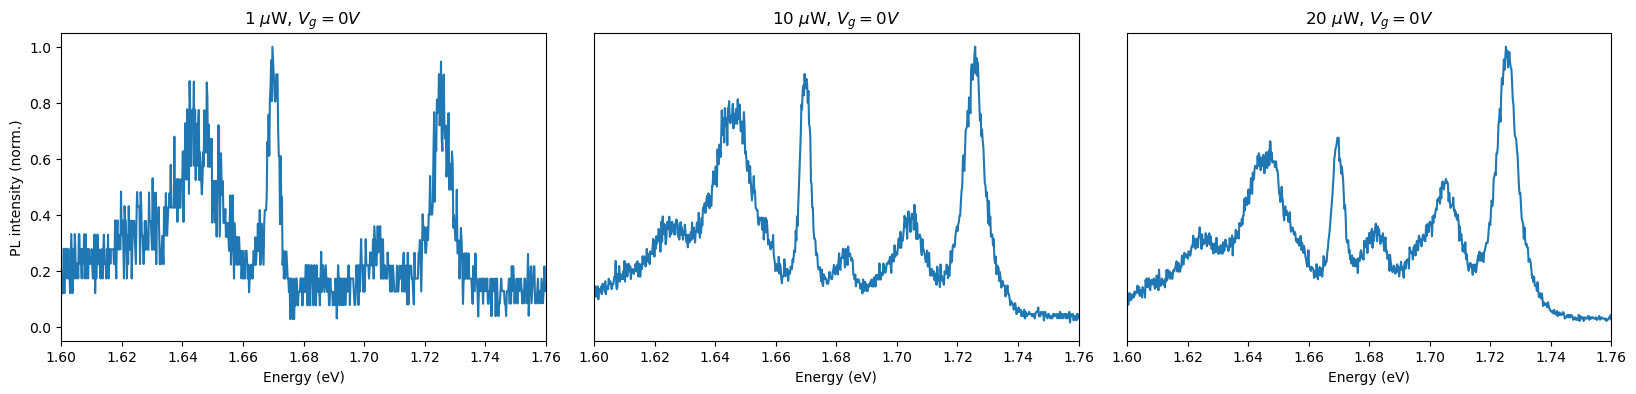

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharey=True, gridspec_kw = {'wspace' : 0.1})

labels = [rf"{power} $\mu$W, $V_g= 0V$" for power in powers]

for ax, scan, label in zip(axes, scans, labels):
    fig, ax, line, ax_twin = plot_spectrum(scan, value = 0.0, ax=ax, normalize = True)

for i, ax in enumerate(axes):
    ax.set_title(labels[i])
    ax.set_xlim([1.6, 1.76])
    if i==0:
        continue
    ax.set_ylabel("")
    ax.tick_params(axis="y", left=False)   # drop the tick marks too

If we wanted to, we could have also plotted the same thing in wavelength.

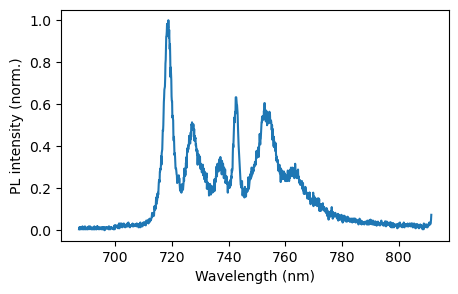

In [9]:
fig, ax, line, ax_twin = plot_spectrum(scans[2], value = 0.0, normalize = True, x_axis='wavelength')

Or have both energy and wavelength

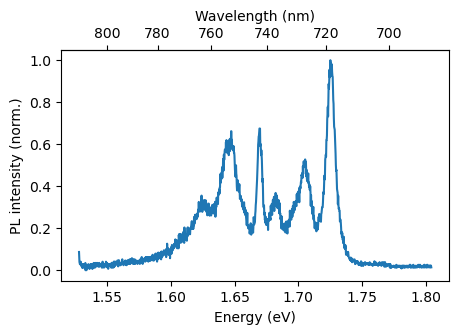

In [10]:
fig, ax, line, ax_twin = plot_spectrum(scans[2], value = 0.0, normalize = True, x_axis='energy', twin_axis = True)

## Fitting spectra

Now we turn to looking at the linewidth of our PL spectra. We will examine the linewidth of the $X_0$ transition which takes place at about 1.73 eV. Looking at the function call of `fitting.fit_lorentzian`, we have

```python
def fit_lorentzian(
    x        : np.ndarray,
    y        : np.ndarray,
    p0       : tuple = None,
    bounds   : tuple = (-np.inf, np.inf),
    baseline : str   = "constant",
) -> FitResult:
```

By default, we have `baseline = "constant"` which fits the case where our spectrum is offset from 0 due to background noise. If we had a sloping background due to other noise sources, we could have passed in `baseline = "linear"`.

So we have to supply our x-axis (the energy) and the spectra. To obtain the spectra at a particular value of our sweep, we can use `scan.get_spectrum_at(value=0.0, axis='bottom_voltage)` which finds the spectrum where the axis variable is `0`. In this case, we pass `bottom_voltage` as the axis to declare to the function that we want the spectrum at `bottom_voltage = 0`. However, since we already declared our sweeping variable when we loaded our scan

```python
scan = AttoCubeSpectralSweep(
    path = ...,
    sweep = "bottom_voltage", # Variable being swept
)
```

this step isn't really required, but we include it here for completeness. 

If we wanted the spectrum at a particular index in our scan, we could have used `scan.get_spectrum_by_index(index=0)`

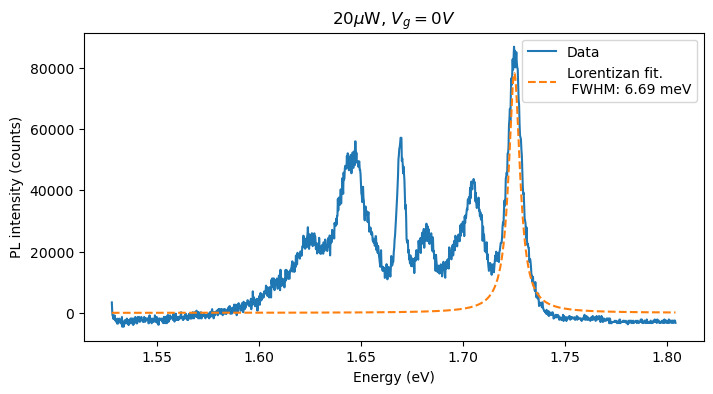

In [11]:
p0 = [78644, 1.73, 0.0067008863727493605] # Initial guess
fit_result = fit_lorentzian(scans[2].energy, scans[2].get_spectrum_at(value=0.0, axis = "bottom_voltage"), p0=p0)

# Extract our Lorentizan parameters
amp_fit = fit_result.params.get('amplitude')
center_fit = fit_result.params.get('center')
fwhm_fit = fit_result.params.get("fwhm")

# Then plot our measured spectrum and the fitted Lorentzian

fig, ax = plt.subplots(figsize = (8,4))

fig, ax, line, ax_twin = plot_spectrum(scan, value = 0.0, ax = ax, label = "Data")
ax.plot(
    scans[2].energy,
    lorentzian(scans[2].energy, amp_fit, center_fit, fwhm_fit),
    linestyle = '--',
    label = f"Lorentizan fit. \n FWHM: {fwhm_fit*1e3:.2f} meV"
)

ax.set_title(r"20$\mu$W, $V_g=0V$")
ax.legend()



## Excitation Power Sweep

In [12]:
scan = AttoCubeSpectralSweep(
    path = sorted(filepath.glob("PL_power_sweep*.csv"))[0],
    geometry = geom,
    sweep = "power",  # Variable being swept
    **SWEEP_DEFAULTS    
)

C:\Users\Brandon\AppData\Local\Temp\ipykernel_33520\41977955.py:1: UserWarning: curated_scales rescaled 'v_bot' 1 -> -1, unit still 'V'. Pass curated_units={'v_bot': ...} to state what the numbers now are — the unit reaches every axis label, __repr__ line and legend entry, so it is a misread otherwise.
  scan = AttoCubeSpectralSweep(
C:\Users\Brandon\AppData\Local\Temp\ipykernel_33520\41977955.py:1: UserWarning: sweep='power' takes only 39 different values across 44 sweep points in 'data\1L-WSe2-PL\PL_power_sweep_26_08_05_15_59_21_iter_0.csv' (0.1951 → 92.21 µW), so it does not label them individually. Plotted against it, points sharing a value land in the same place and only one of them is drawn. If these points are a nest, declare it with fast_sweep= and slow_sweep=; if they are repeat measurements at each setting, sweep=None gives the flat index.
  scan = AttoCubeSpectralSweep(


Just like before, we could plot a spectral map

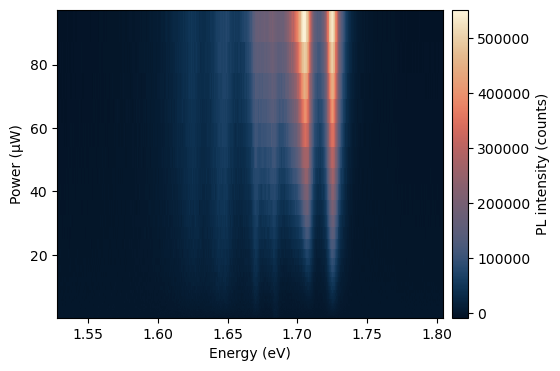

In [13]:
fig, ax, mesh = plot_spectral_map(
    scan,
    cmap = 'cmc.lipari'
)

It can be difficult to see how the spectra change as a function of power, so we can instead stack individual spectra on top of each other in a line plot. To do so, we call `plot_power_series`, which plots spectra against the sweeping variable.

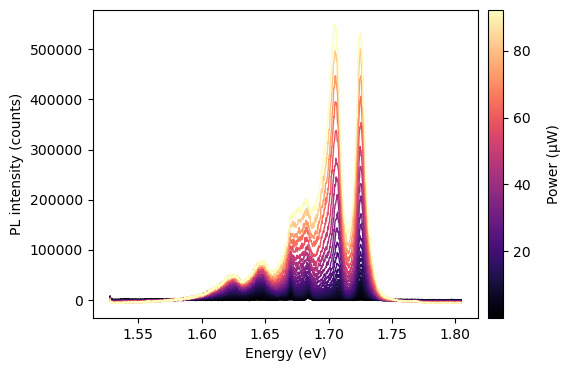

In [14]:
fig, ax, cb, lines, ax_twin = plot_spectral_series(scan)

The way this is plotted, it can be difficult to see how the spectrum changes with power. To see the changes more clearly, we can do two things: we can first thin down the number of spectra plotted using the argument `sweep_step` and we can also space out the spectrum vertically using `spectrum_offset`. `spectrum_offset` shifts each successive spectrum plotted by its parameter value. The value is in real units, so it should be selected by considering the peak counts in our data.

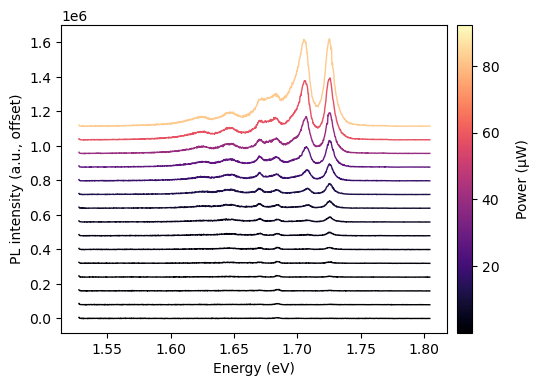

In [15]:
fig, ax, cb, lines, ax_twin = plot_spectral_series(scan, spectrum_offset = 80000, sweep_step = 3)